#### Initial exploration of ERA5 data. <br>
##### Downloaded from https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-single-levels?tab=form with the following settings:<br>
- Product Type: Reanalysis
- Variable: 2m temperature
- Other: Land-sea mask, Sea-ice cover
- Year: 2021
- Month: June
- Day: all
- Time: all
- Area: Lat 47 - 50 N, Long -124 to -122
<br>
##### Took about 2 min for the site to prepare the data, file is 510 kB in size. Not sure if I did the lat/long correctly:
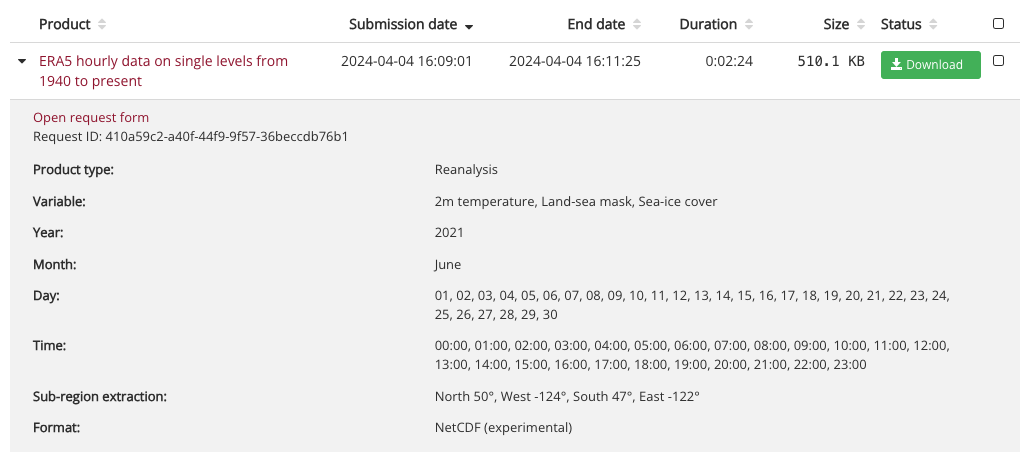

In [139]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [3]:
# filename ERA5_T2m_202106_PugetSound.nc
dset = xr.open_dataset('/Users/tedscott/Google Drive/My Drive/PhD Work/Data/ERA5_T2m_202106_PugetSound.nc')
print(dset)

<xarray.Dataset>
Dimensions:    (longitude: 9, latitude: 13, time: 720)
Coordinates:
  * longitude  (longitude) float32 -124.0 -123.8 -123.5 ... -122.5 -122.2 -122.0
  * latitude   (latitude) float32 50.0 49.75 49.5 49.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 2021-06-01 ... 2021-06-30T23:00:00
Data variables:
    t2m        (time, latitude, longitude) float32 ...
    lsm        (time, latitude, longitude) float32 ...
    siconc     (time, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-04-04 23:11:24 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...


In [4]:
print(dset['t2m'])

<xarray.DataArray 't2m' (time: 720, latitude: 13, longitude: 9)>
[84240 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -124.0 -123.8 -123.5 ... -122.5 -122.2 -122.0
  * latitude   (latitude) float32 50.0 49.75 49.5 49.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 2021-06-01 ... 2021-06-30T23:00:00
Attributes:
    units:      K
    long_name:  2 metre temperature


(array([  523.,  3761., 15067., 27734., 18640., 10471.,  4665.,  2158.,
          982.,   239.]),
 array([270.99243164, 275.47418213, 279.9559021 , 284.43765259,
        288.91937256, 293.40112305, 297.88287354, 302.36459351,
        306.84634399, 311.32806396, 315.80981445]),
 <BarContainer object of 10 artists>)

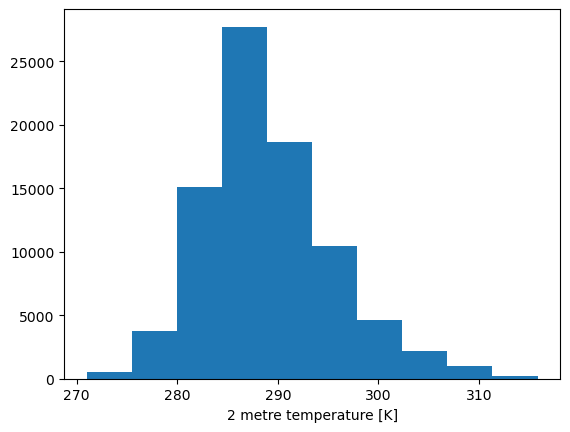

In [5]:
dset['t2m'].plot()

In [6]:
# not what I expected but prob need to filter to a single hour on a single day
dset.t2m.time.data[:20]

array(['2021-06-01T00:00:00.000000000', '2021-06-01T01:00:00.000000000',
       '2021-06-01T02:00:00.000000000', '2021-06-01T03:00:00.000000000',
       '2021-06-01T04:00:00.000000000', '2021-06-01T05:00:00.000000000',
       '2021-06-01T06:00:00.000000000', '2021-06-01T07:00:00.000000000',
       '2021-06-01T08:00:00.000000000', '2021-06-01T09:00:00.000000000',
       '2021-06-01T10:00:00.000000000', '2021-06-01T11:00:00.000000000',
       '2021-06-01T12:00:00.000000000', '2021-06-01T13:00:00.000000000',
       '2021-06-01T14:00:00.000000000', '2021-06-01T15:00:00.000000000',
       '2021-06-01T16:00:00.000000000', '2021-06-01T17:00:00.000000000',
       '2021-06-01T18:00:00.000000000', '2021-06-01T19:00:00.000000000'],
      dtype='datetime64[ns]')

## Playing with some plotting and cartopy <br>

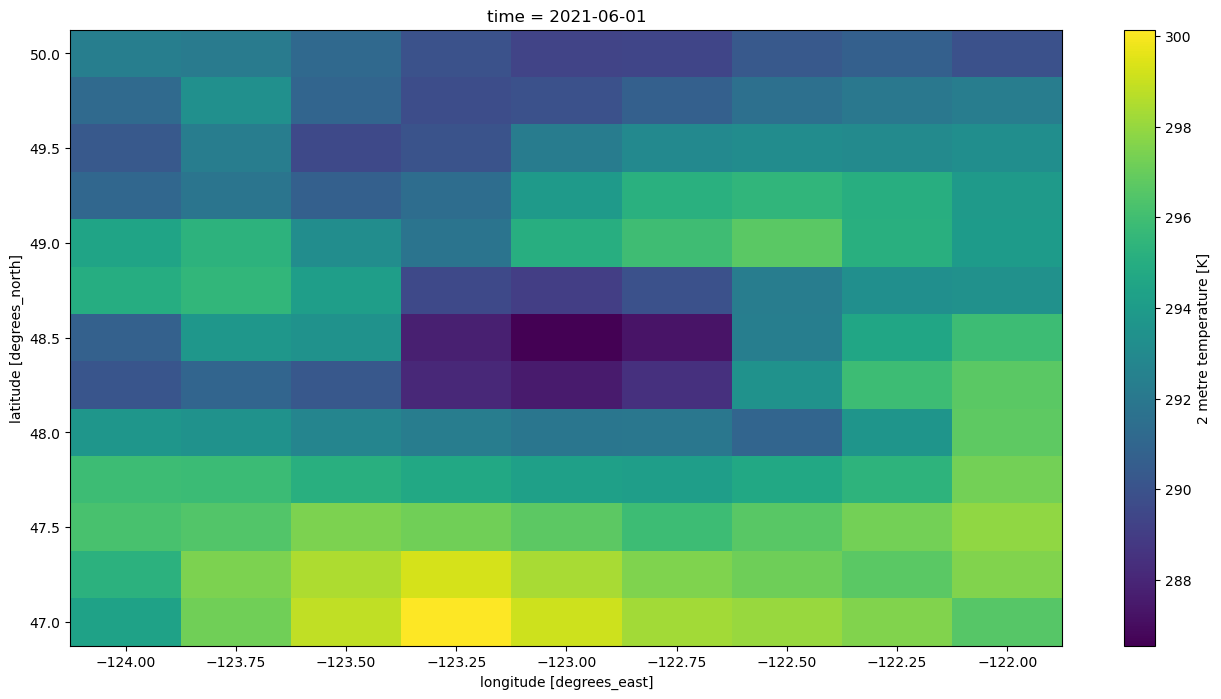

In [7]:
# subset for one timestamp? Using hints from 
# https://github.com/Tjmahir20/Analysis_of_ERA5_Dataset_with_Python/blob/main/01_Code/01_Reading_%26_Plotting_Data.ipynb
plt.figure(figsize=(16,8))
dset.t2m.isel(time=0).plot(x="longitude")

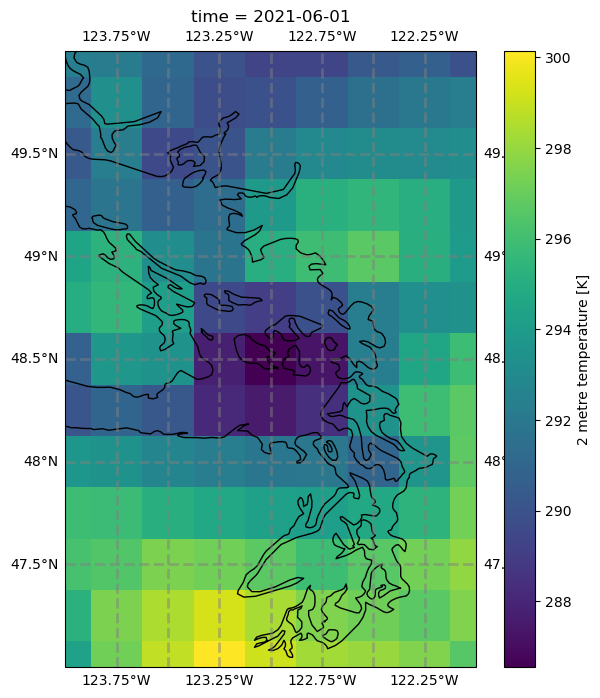

In [112]:
fig = plt.figure(figsize=[16,8])

# 111 means 1 row, 1 col and index 1
ax = fig.add_subplot(1,2,1, projection=ccrs.PlateCarree(central_longitude=-123))
dset.t2m.isel(time=0).plot(ax=ax,transform=ccrs.PlateCarree())
ax.coastlines()
ax.set_xlim(-1,1)
ax.set_ylim(47,50)
gl = ax.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)

#ax.plot(projection=ccrs.PlateCarree(central_longitude=-123))
#dset.t2m.isel(time=0).plot(ax=ax, x="longitude")
#ax2 = fig.add_subplot(1,2,2)#,sharex=ax, sharey=ax)
#dset.t2m.isel(time=0).plot(ax=ax2, x="longitude") #,  vmax=300, cmap='jet')
                   #)

#ax2.set_xlabel("longitude")

plt.show()

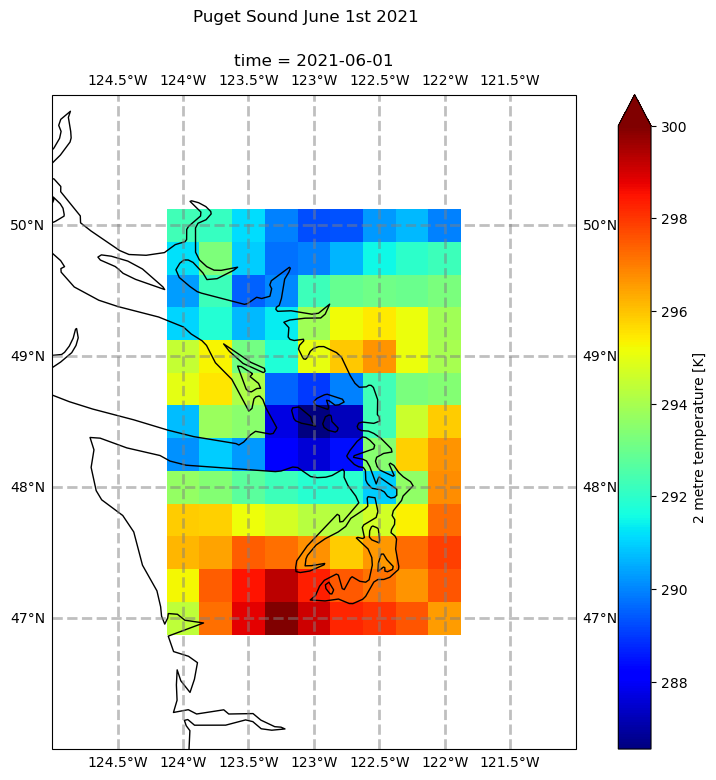

In [88]:
projPC = ccrs.PlateCarree()
lonW = -125
lonE = -121
latS = 46
latN = 51
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
res = '50m'
fig = plt.figure(figsize=(11, 8.5))
plt.suptitle('Puget Sound June 1st 2021')
ax = plt.subplot(1, 1, 1, projection=projPC)

gl = ax.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.coastlines(resolution=res, color='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
#ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue');

dset.t2m.isel(time=0).plot(ax=ax, vmax=300, cmap='jet',
                   transform=ccrs.PlateCarree())
#ax.coastlines()

plt.show()

### Try the land-sea mask

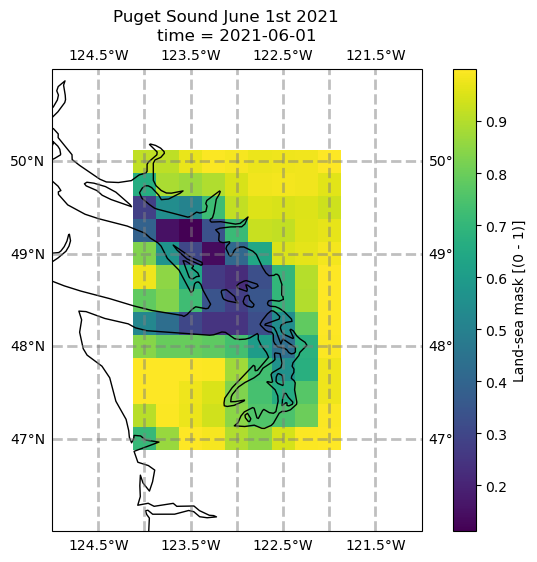

In [124]:
projPC = ccrs.PlateCarree()
lonW = -125
lonE = -121
latS = 46
latN = 51
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
res = '50m'
fig = plt.figure(figsize=(8, 6))
plt.suptitle('Puget Sound June 1st 2021')
ax = plt.subplot(1, 1, 1, projection=projPC)

gl = ax.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.coastlines(resolution=res, color='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
#ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue');

dset.lsm.isel(time=0).plot(ax=ax, #vmax=300, cmap='jet',
                   transform=ccrs.PlateCarree())
#ax.colorbar(orientation='horizontal');
#ax.coastlines()

plt.show()

### OK, now try to sort out max temp for each day

In [115]:
dset.t2m.isel(time=0)

<xarray.DataArray 't2m' (latitude: 13, longitude: 9)>
[117 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -124.0 -123.8 -123.5 ... -122.5 -122.2 -122.0
  * latitude   (latitude) float32 50.0 49.75 49.5 49.25 ... 47.5 47.25 47.0
    time       datetime64[ns] 2021-06-01
Attributes:
    units:      K
    long_name:  2 metre temperature

In [119]:
dset['t2m'].max()

<xarray.DataArray 't2m' ()>
array(315.80981445)

In [162]:
#[dt.day for date in (dset.time)]
pd.to_datetime(dset.t2m.time.data).day

#dset.t2m.time.data[0].dt.day

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30],
      dtype='int32', length=720)

In [163]:
dset.t2m.isel(time=0)

#[dset.t2m.isel(time=i).max() for i in np.arange(len(dset.time))]

<xarray.DataArray 't2m' (latitude: 13, longitude: 9)>
array([[292.3127 , 292.13492, 291.15625, 289.9533 , 289.2694 , 289.31863,
        290.26788, 290.67206, 289.93552],
       [291.19318, 293.31668, 290.91965, 289.71255, 289.92798, 290.6406 ,
        291.50366, 291.97488, 292.23407],
       [290.28705, 292.2717 , 289.52518, 290.04083, 292.22656, 292.94122,
        293.1074 , 292.97678, 293.23666],
       [291.02768, 291.8087 , 290.6878 , 291.3553 , 293.87677, 295.18915,
        295.44562, 295.06674, 293.89456],
       [294.47653, 295.28354, 293.1662 , 291.7615 , 295.04486, 295.93735,
        296.65405, 295.1071 , 293.97458],
       [294.97443, 295.50784, 294.09973, 289.56415, 289.0157 , 289.93756,
        292.2792 , 293.2558 , 293.38507],
       [290.7049 , 293.75778, 293.49994, 287.7361 , 286.5489 , 287.27176,
        292.29492, 294.58597, 295.86346],
       [290.1311 , 290.93332, 290.246  , 288.05072, 287.55286, 288.41797,
        293.44934, 295.8457 , 296.67798],
       [293.67572, 293.41992, 292.74014, 292.23816, 291.90237, 291.9318 ,
        290.9121 , 293.62305, 296.75186],
       [295.86896, 295.82587, 295.14267, 294.6995 , 294.2228 , 294.1312 ,
        294.6817 , 295.35126, 297.26202],
       [296.18558, 296.4393 , 297.45285, 297.20868, 296.7327 , 295.87305,
        296.59592, 297.26752, 297.86728],
       [295.2459 , 297.46652, 298.48413, 299.2713 , 298.3672 , 297.4884 ,
        297.13074, 296.67184, 297.5821 ],
       [294.36917, 297.17587, 298.83566, 300.14053, 299.0976 , 298.23453,
        298.01978, 297.54517, 296.55283]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -124.0 -123.8 -123.5 ... -122.5 -122.2 -122.0
  * latitude   (latitude) float32 50.0 49.75 49.5 49.25 ... 47.5 47.25 47.0
    time       datetime64[ns] 2021-06-01
Attributes:
    units:      K
    long_name:  2 metre temperature

### <br>Example of resampling hourly to daily to get max temp for each grid cell <br><br>

In [167]:
dset_daily = dset.resample(time='D').max(dim="time")
dset_daily

<xarray.Dataset>
Dimensions:    (longitude: 9, latitude: 13, time: 30)
Coordinates:
  * longitude  (longitude) float32 -124.0 -123.8 -123.5 ... -122.5 -122.2 -122.0
  * latitude   (latitude) float32 50.0 49.75 49.5 49.25 ... 47.5 47.25 47.0
  * time       (time) datetime64[ns] 2021-06-01 2021-06-02 ... 2021-06-30
Data variables:
    t2m        (time, latitude, longitude) float32 297.5 298.3 ... 299.9 299.5
    lsm        (time, latitude, longitude) float32 0.9151 0.9129 ... 0.9995
    siconc     (time, latitude, longitude) float32 nan nan nan ... nan nan nan
Attributes:
    Conventions:  CF-1.6
    history:      2024-04-04 23:11:24 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

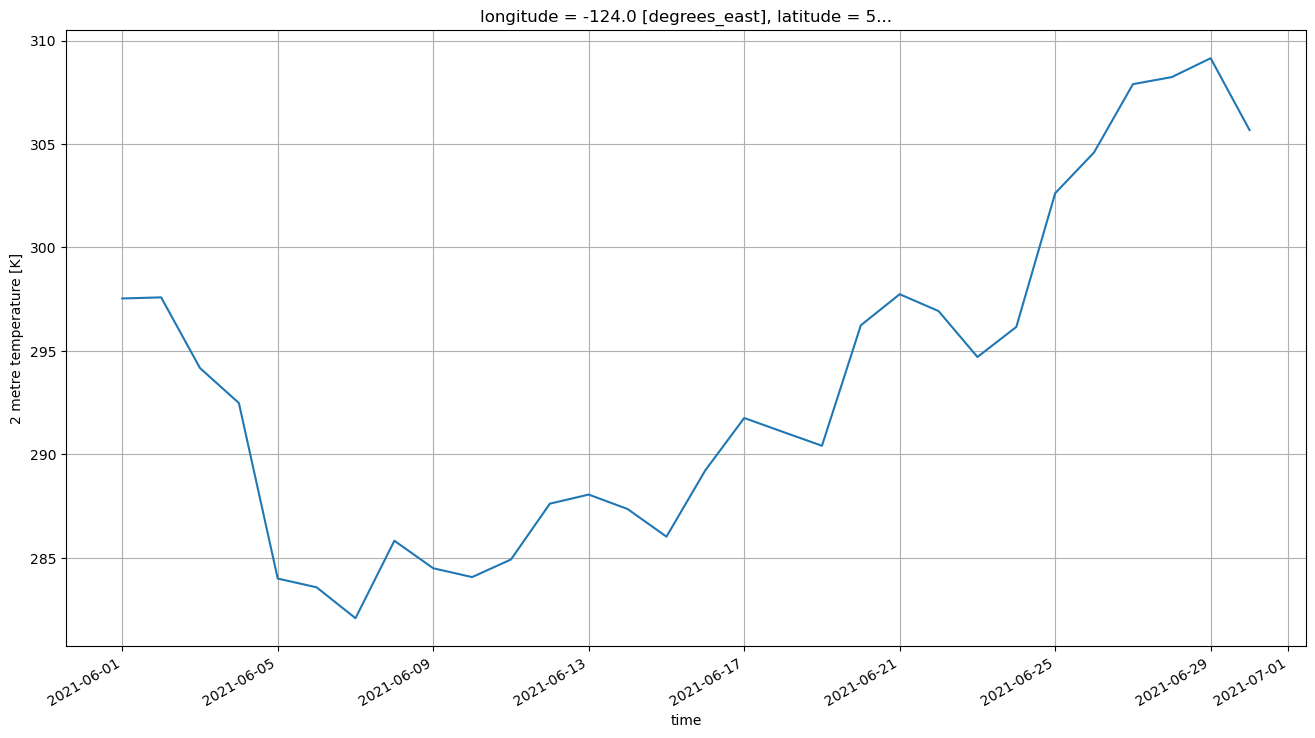

In [188]:

plt.figure(figsize=(16,8))
dset_daily.t2m.isel(latitude=0,longitude=0).plot()
#plt.legend()
plt.grid()